# Pose Control based on Lyapunov Estabilization theory

- Como se faz um projeto não-linear
- A chegada na equação de Lyapunov

## Configuring the environment

In [8]:
import numpy as np
import math
import matplotlib.pyplot as plt
from coppeliasim_zmqremoteapi_client import RemoteAPIClient
import os

# Parameters of Turtlebot 3
wheel_radius = 0.033
robot_width = 0.287

# Initialize the Remote API
client = RemoteAPIClient()
sim = client.require('sim')

# Open the turtlebot3 scene 
# simulation_file = os.getcwd()+'/turtlebot3_pose_estabilization.ttt'
# sim.loadScene(simulation_file)

# Use the stepping mode
sim.setStepping(True)   

# Configure the handles
Turtlebot3 = sim.getObjectHandle('/Turtlebot3')
leftMotor = sim.getObjectHandle('/Turtlebot3/left_motor')
rightMotor = sim.getObjectHandle('/Turtlebot3/right_motor')
Goal = sim.getObjectHandle('/ReferenceFrame')

# Error tolerance
min_error = 0.2

# Robot Limits - considering the kinematic model
maxv = 0.26
maxw = 1.82

## Utils

In [9]:
def draw_robot(x, y, theta, ax, scale=1.0, **kwargs):
    """
    Desenha o contorno do robô no gráfico fornecido.
    
    Parâmetros:
    x, y  : Posição do centro do robô (m)
    theta : Orientação do robô (rad)
    ax    : Objeto Axes do matplotlib onde o robô será desenhado
    scale : Escala do desenho (para ajustar o tamanho visualmente)
    **kwargs: Argumentos opcionais de plotagem (ex: color='b', linestyle='--')
    """
    p = np.zeros((12, 3))
    
    p[:] = [
        [ 1,    1/7,  1/scale],
        [-3/7,  1,    1/scale],
        [-5/7,  6/7,  1/scale],
        [-5/7,  5/7,  1/scale],
        [-3/7,  2/7,  1/scale],
        [-3/7,  0,    1/scale],
        [-3/7, -2/7,  1/scale],
        [-5/7, -5/7,  1/scale],
        [-5/7, -6/7,  1/scale],
        [-3/7, -1,    1/scale],
        [ 1,   -1/7,  1/scale],
        [ 1,    1/7,  1/scale]
    ]
    
    p = scale * p
    
    r = np.array([
        [np.cos(theta),  np.sin(theta)],
        [-np.sin(theta), np.cos(theta)],
        [x,              y]
    ])
    
    p_transf = np.dot(p, r)
    
    X_plot = p_transf[:, 0]
    Y_plot = p_transf[:, 1]
    
    if 'color' not in kwargs and 'c' not in kwargs:
        kwargs['color'] = 'blue'
        
    ax.plot(X_plot, Y_plot, **kwargs)


def calcular_erros_trajetoria(t, pose_1, pose_2):
    """
    Calcula o erro entre a pose de dois modelos distintos.
    """
    
    pose_1 = np.array(pose_1)
    pose_2 = np.array(pose_2)
    
    erro_posicao = np.linalg.norm(pose_1[:, 0:2] - pose_2[:, 0:2], axis=1)
    
    diff_theta = pose_1[:, 2] - pose_2[:, 2]
    erro_orientacao = np.arctan2(np.sin(diff_theta), np.cos(diff_theta))
    
    rmse_pos = np.sqrt(np.mean(erro_posicao**2))
    rmse_ori = np.sqrt(np.mean(erro_orientacao**2))
    
    erro_final_pos = erro_posicao[-1]

    print(f"RMSE Posição: {rmse_pos:.4f} m")
    print(f"RMSE Orientação: {rmse_ori:.4f} rad")
    print(f"Erro Final de Posição: {erro_final_pos:.4f} m")
    
    return {
        "tempo": t,
        "erro_pos_t": erro_posicao,
        "erro_theta_t": erro_orientacao,
        "rmse_pos": rmse_pos,
        "rmse_theta": rmse_ori
    }

def plotar_erros(resultados_erro):
    """
    Plota os gráficos de erro ao longo do tempo.
    """
    t = resultados_erro["tempo"]
    e_pos = resultados_erro["erro_pos_t"]
    e_theta = resultados_erro["erro_theta_t"]
    
    fig, ax = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
    
    # Gráfico de Erro de Posição
    ax[0].plot(t, e_pos, 'r-', label='Erro Euclidiano')
    ax[0].set_ylabel('Erro de Posição [m]')
    ax[0].set_title('Evolução do Erro de Trajetória (Dinâmico vs Coppelia)')
    ax[0].grid(True)
    ax[0].legend()
    
    # Gráfico de Erro de Orientação
    ax[1].plot(t, e_theta, 'b-', label='Erro Angular')
    ax[1].set_ylabel('Erro de Orientação [rad]')
    ax[1].set_xlabel('Tempo [s]')
    ax[1].grid(True)
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()

def pose_no_tempo(time, x, y, theta):
    """
    Plotar a pose do robô ao longo do tempo
    """
    plt.figure(figsize=(12, 6))
    plt.plot(time, x , label='$x_a(t)$ [m]', lw=2)
    plt.plot(time, y, label='$y_a(t)$ [m]', lw=2)
    plt.plot(time, theta, label='$\\theta(t)$ [rad]', lw=2)
    plt.xlabel('Tempo [s]')
    plt.ylabel('Posição [m] / Orientação [rad]')
    plt.title('Pose do Robô Extraída do CoppeliaSim no tempo')
    plt.legend()
    plt.grid(True)
    plt.show()
    return

# Normalize angle to the range [-pi,pi)
def normalize_angle(angle):
    return np.mod(angle+np.pi, 2*np.pi) - np.pi

## Simulation Loop - Aicardi

In [10]:
# Initialize the simulation
sim.startSimulation()

# Control gains
gamma = 1/3
h = 1/9
k = 1/2

time_history = []
aicardi_robot_pose_history = []

while True:

    # Capture the robot pose from simulation
    TBPos=sim.getObjectPosition(Turtlebot3,-1)
    TBXOri=sim.getObjectOrientation(Turtlebot3,-1)
    qTurtlebot = np.array([TBPos[0], TBPos[1], TBXOri[2]])

    # Capture the goal pose
    Goal_Pos = sim.getObjectPosition(Goal,-1)
    Goal_Ori = sim.getObjectOrientation(Goal,-1)
    qGoal = np.array([Goal_Pos[0], Goal_Pos[1],Goal_Ori[2]])

    time_history.append(sim.getSimulationTime())
    aicardi_robot_pose_history.append(qTurtlebot)

    # Global States
    dx, dy, dth = qGoal - qTurtlebot

    # Transform to Aicardi states
    e = math.sqrt(dx**2 + dy**2)
    alpha = normalize_angle(np.arctan2(dy,dx) - qTurtlebot[2])
    theta_aicardi = normalize_angle(qGoal[2] - np.arctan2(dy,dx))

    # Stopping condition
    if e < min_error:
        # Goal achieved
        print("Alvo alcançado!")
        sim.stopSimulation()
        break

    # Calculate linear and angular velocities from (6) and (9)
    # u = gamma * cos(alpha) * e
    v = gamma * math.cos(alpha) * e
    
    # omega = k*alpha + gamma * (cos(alpha)*sin(alpha)/alpha) * (alpha + h*theta)
    omega = k * alpha + gamma * ((math.cos(alpha) * math.sin(alpha))/alpha) * (alpha + h * theta_aicardi)

    # Saturation Limits
    v = max(min(v, maxv), -maxv)
    omega = max(min(omega, maxw), -maxw) 

    #  DDMR Inverse Kinematics
    w_right = (v + (omega * robot_width / 2)) / wheel_radius
    w_left  = (v - (omega * robot_width / 2)) / wheel_radius

    # Send commands
    sim.setJointTargetVelocity(leftMotor, w_left)
    sim.setJointTargetVelocity(rightMotor, w_right)

    print(f"Erro: {e} | Alpha: {alpha} | Theta: {theta_aicardi}")
    print(f"v: {v}, omega: {omega}\n")
    # Step the simulation
    sim.step()

Erro: 1.7869977616102406 | Alpha: -1.6750276187678086 | Theta: -1.4665650348221768
v: -0.06197466894216595, omega: -0.7996655909808335

Erro: 1.7893152323265438 | Alpha: -1.635069178571622 | Theta: -1.468057048391981
v: -0.038308409515986123, omega: -0.7940378152341686

Erro: 1.7917223361069579 | Alpha: -1.5945954069115302 | Theta: -1.4691920959520695
v: -0.014212439407283577, omega: -0.7885558505297362

Erro: 1.7941946687936952 | Alpha: -1.5547407489297091 | Theta: -1.4697847319734048
v: 0.009601864860316766, omega: -0.7832833748499277

Erro: 1.796563370229225 | Alpha: -1.516015260074841 | Theta: -1.4696297626691974
v: 0.032789480191557224, omega: -0.7781943917695148

Erro: 1.7989289284371388 | Alpha: -1.4784903661423883 | Theta: -1.468621797646914
v: 0.05527205295764529, omega: -0.7732160234031968

Erro: 1.8011123397993665 | Alpha: -1.4414222963485006 | Theta: -1.4669923026760232
v: 0.07745589341471873, omega: -0.7681786276063917

Erro: 1.8030123560229714 | Alpha: -1.4054003815658689

### Plot the results for Aicardi algorithm

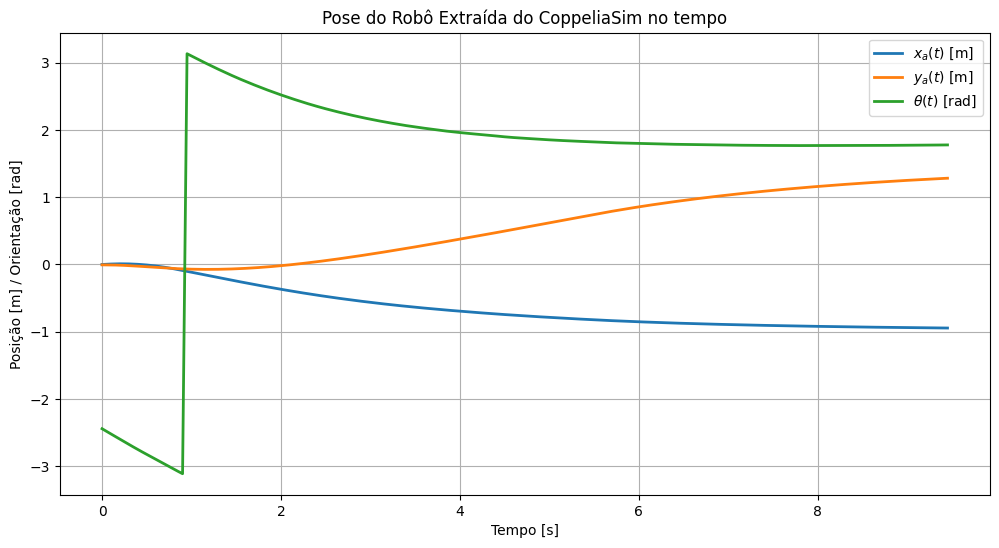

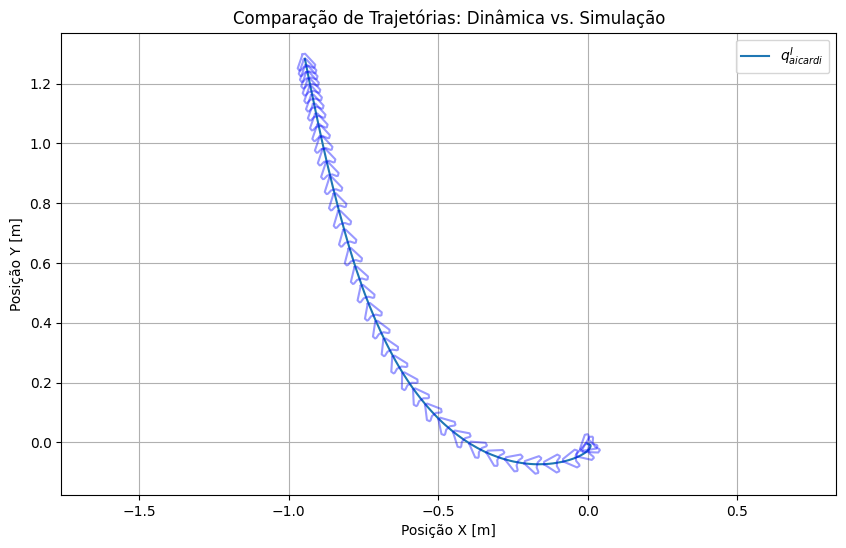

In [11]:
time = np.array(time_history)
aicardi_robot_pose = np.array(aicardi_robot_pose_history)

pose_no_tempo(time,aicardi_robot_pose[:,0], aicardi_robot_pose[:,1], aicardi_robot_pose[:,2])

# P Plot robot pose in X and Y
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(aicardi_robot_pose[:,0], aicardi_robot_pose[:,1], label='$q^I_{aicardi}$', lw=1.5)
scale = 0.03 
step = 5

for i in range(0, len(time)-1, step):
    draw_robot(aicardi_robot_pose[i,0], aicardi_robot_pose[i,1], aicardi_robot_pose[i,2], ax, scale=scale, color='blue', alpha=0.4)
    

ax.set_title('Comparação de Trajetórias: Dinâmica vs. Simulação')
ax.set_xlabel('Posição X [m]')
ax.set_ylabel('Posição Y [m]')
ax.axis('equal')
ax.grid(True)
ax.legend()
plt.show()

## Simulation Loop - Benbouabdallah

In [ ]:
# Initialize the Remote API
client = RemoteAPIClient()
sim = client.require('sim')

# Use the stepping mode
sim.setStepping(True)   

# Configure the handles
Turtlebot3 = sim.getObjectHandle('/Turtlebot3')
leftMotor = sim.getObjectHandle('/Turtlebot3/left_motor')
rightMotor = sim.getObjectHandle('/Turtlebot3/right_motor')
Goal = sim.getObjectHandle('/ReferenceFrame')

# Initialize the simulation
sim.startSimulation()

# Control gains
Kv = 2.07
Kw = 1.49

Dd = 0.2

while True:

    # Capture the robot pose from simulation
    TBPos=sim.getObjectPosition(Turtlebot3,-1)
    TBXOri=sim.getObjectOrientation(Turtlebot3,-1)
    qTurtlebot = np.array([TBPos[0], TBPos[1], TBXOri[2]])

    # Capture the goal pose
    Goal_Pos = sim.getObjectPosition(Goal,-1)
    Goal_Ori = sim.getObjectOrientation(Goal,-1)
    qGoal = np.array([Goal_Pos[0], Goal_Pos[1],Goal_Ori[2]])

    # Global States
    dx, dy, dth = qGoal - qTurtlebot
    # Transform to Benbouabdallah states
    D = math.sqrt(dx**2 + dy**2)
    alpha = normalize_angle(-np.arctan2(dy,dx) + qTurtlebot[2])
    theta_aicardi = normalize_angle(qGoal[2] - np.arctan2(dy,dx))
    ed = -Dd + D

    # Stopping condition
    if D < Dd:
        # Goal achieved
        print("Alvo alcançado!")
        sim.stopSimulation()
        break

    # Calculate linear and angular velocities from (14)
    # v_tt = -Kv * ed * math.cos(alpha)
    v_tt = Kv * ed * math.cos(alpha)
    
    # omega = k*alpha + gamma * (cos(alpha)*sin(alpha)/alpha) * (alpha + h*theta)
    omega_tt = -Kw * alpha - (v_tt/D) * math.sin(alpha)

    # Saturation Limits
    # v_tt = max(min(v_tt, maxv), -maxv)
    # omega_tt = max(min(omega_tt, maxw), -maxw) 


    #  DDMR Inverse Kinematics
    w_right = (v_tt + (omega_tt * robot_width / 2)) / wheel_radius
    w_left  = (v_tt - (omega_tt * robot_width / 2)) / wheel_radius

    # Send commands
    sim.setJointTargetVelocity(leftMotor, w_left)
    sim.setJointTargetVelocity(rightMotor, w_right)

    print(f"Erro: {D} | Alpha: {alpha} | Theta: {theta_aicardi}")
    print(f"v: {v_tt}, omega: {omega_tt}\n")
    # Step the simulation
    sim.step()